**This version inherits from FullPipeline_v1.5_ms3.ipynb**

*This version modified Decoder; added pre-&post-UNO modules to improve UNO performance*

This version is the SECOND experiment described in MS2 report: improved late integration.

In [1]:
from model_v2_w6ms3.DataLoader import TempFlowDataset_disp
from model_v2_w6ms3.neuralop_seg.uno import UNO

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

Data prep

In [2]:

dataset = TempFlowDataset_disp(
    root = '../../Data',
    split = 'training',
    image_folder = 'image_2',
    flow_type = 'flow_occ',
    disp_type= 'disp_occ',
    seq_len = 4, # 3 flows
    center_frame_idx = 10,
    crop_size = (352, 1216),
    normalize = True,
    stats_in = 'stats.json',
    return_pair_only = False,
)

train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [3]:
batch = next(iter(train_loader))
print(batch['imgs'].shape)

torch.Size([2, 4, 3, 352, 1216])


Encoders

In [142]:
import importlib
import model_v2_w6ms3.Encoders as Encoders
importlib.reload(Encoders)
from model_v2_w6ms3.Encoders import *

import model_v2_w6ms3.Decoders as Decoders
importlib.reload(Decoders)
from model_v2_w6ms3.Decoders import *

import model_v2_w6ms3.Trainers as Trainers
importlib.reload(Trainers)
from model_v2_w6ms3.Trainers import *

In [143]:
# -------------------------
# 1. Pairwise motion encoder
# -------------------------
pair_encoder = SequencePairEncoder(
    feat_ch=64,         # backbone feature channels
    corr_radius=4,      # local cost-volume radius
    embed_ch=128,       # output pair embedding channels
    predict_flow=True   # also return coarse pairwise flow_init
)

# -------------------------
# 2. Raw visual branch
# -------------------------
visual_branch = VisualBranchCNN(
    in_ch=3,
    base_ch=32,
    out_ch=64
)

# -------------------------
# 3. Motion branch
# -------------------------
# input should match pair_encoder embed_ch
motion_branch = MotionBranchCNN(
    in_ch=128,
    hidden_ch=128,
    out_ch=64
)

# -------------------------
# 4. Motion-Vision-Light Temporal fusion
# -------------------------
# should return [B, Tm, hidden_ch, H, W]
fusion = SpatialTemporalFusion_timeAware(
    visual_ch=64,
    motion_ch=64,
    hidden_ch=128,
    out_ch=128
)

# -------------------------
# 5. UNO
# -------------------------
uno = UNO(
    in_channels=403,
    out_channels=128,
    hidden_channels=64,
    lifting_channels=64,
    projection_channels=128,
    positional_embedding='grid',
    n_layers=4,
    uno_out_channels=[64, 96, 96, 64],
    uno_n_modes=[[12, 16], [10, 12], [10, 12], [12, 16]],
    uno_scalings=[[1.0, 1.0], [0.5, 0.5], [2.0, 2.0], [1.0, 1.0]],
    fno_skip="linear",
    horizontal_skip="linear",
    channel_mlp_skip="linear",
)

uno_residual_head = UNOLatentResidualHead(
    out_ch=128, 
    latent_ch=128,
    num_pairs=3 # Should be Tm
)

# -------------------------
# 6. Decoder
# -------------------------
decoder = FlowDecoder(
    in_ch=128,            # must match fusion output channels; hard code #prev_flows=2
    hidden_ch=128,
    upsample=8,    # use 4 if fusion output is H/4, use 8 if H/8. Match upsample x.
    use_prev_flow=True
)

Train

In [144]:
def forward_pipeline(imgs, pair_encoder, visual_branch, motion_branch, fusion, 
                     uno, uno_residual_head, decoder, valid=None):
    """
    imgs: [B, T, 3, H, W]

    Returns dict with:
      flows:      [B, Tm, 2, H, W]
      flow_inits: [B, Tm, 2, h, w] or None
      pair_feats: [B, Tm, Cp, h, w]
      corrs:      [B, Tm, K, h, w]
      fused_seq:  [B, Tm, Cf, h, w]
    """
    pair_out = pair_encoder(imgs)
    pair_feats = pair_out["pair_feats"]      # [B, Tm, 128, h, w]
    flow_inits = pair_out["flow_inits"]      # [B, Tm, 2, h, w] or None
    corrs = pair_out["corrs"]
    
    B, Tm, _, h, w, = flow_inits.shape

    visual_feats = visual_branch(imgs)       # [B, T, 64, h, w]
    motion_feats = motion_branch(pair_feats) # [B, Tm, 64, h, w]
    
    fused_seq = fusion(visual_feats, motion_feats)  # [B, Tm, 128, h, w]
    
    valid_lowres = None
    if valid is not None:
        valid_lowres = downsample_valid_mask(valid, size_hw=(h, w)) # [B, 1, h, w]
    
    uno_input = build_uno_input_2d(fused_seq=fused_seq,
                                   flow_inits=flow_inits,
                                   valid_mask=valid_lowres,)
    
    uno_feat = uno(uno_input).to(device)
    
    latent_del = uno_residual_head(uno_feat, B=B, Tm=Tm, H=h, W=w)
    refined_seq = fused_seq + latent_del
    
    flows, flow_res = decoder(refined_seq, flow_inits=None) # KEEP flow_inits=None, otw the system collapses

    return {
        "flows": flows,
        'flow_res': flow_res,
        "flow_inits": flow_inits,
        "pair_feats": pair_feats,
        "corrs": corrs,
        "fused_seq": fused_seq,
        'refined_seq': refined_seq,
        'uno_input': uno_input,
        'uno_feat': uno_feat,
        'latent_del': latent_del,
        'valid_lowres': valid_lowres,
    }

class Trainer:
    def __init__(
        self,
        pair_encoder,
        visual_branch,
        motion_branch,
        fusion,
        uno,
        uno_residual_head,
        decoder,
        optimizer,
        device,
        lambda_epe=1.0,
        lambda_temp=0.02,
        lambda_smooth=0.01,
        lambda_self=0.02,
        lambda_flow_res=0.01,
        lambda_init_improve=0.001,
        lambda_mag=0.02,
        lambda_latent_delta=0.001
    ):
        self.pair_encoder = pair_encoder
        self.visual_branch = visual_branch
        self.motion_branch = motion_branch
        self.fusion = fusion
        self.uno = uno
        self.uno_residual_head = uno_residual_head
        self.decoder = decoder
        self.optimizer = optimizer
        self.device = device
        self.lambda_epe = lambda_epe
        self.lambda_temp = lambda_temp
        self.lambda_smooth = lambda_smooth
        self.lambda_self = lambda_self
        self.lambda_mag = lambda_mag
        self.lambda_flow_res = lambda_flow_res
        self.lambda_init_improve = lambda_init_improve
        self.lambda_latent_delta = lambda_latent_delta

    def train_mode(self):
        self.pair_encoder.train()
        self.visual_branch.train()
        self.motion_branch.train()
        self.fusion.train()
        self.uno.train()
        self.decoder.train()

    def eval_mode(self):
        self.pair_encoder.eval()
        self.visual_branch.eval()
        self.motion_branch.eval()
        self.fusion.eval() 
        self.uno.eval()
        self.decoder.eval()

    def train_step(self, batch):
        self.train_mode()

        imgs = batch["imgs"].to(self.device)                  # [B, T, 3, H, W]
        gt_flow = batch["flow"].to(self.device)               # [B, 2, H, W]
        valid = batch["valid"].to(self.device)                # [B, H, W] or [B,1,H,W]
        src_idx = batch["src_idx_in_seq"].to(self.device)     # [B]
        img_src = batch["img_src"].to(self.device)            # [B, 3, H, W]
        img_tgt = batch["img_tgt"].to(self.device)            # [B, 3, H, W]

        out = forward_pipeline(
            imgs,
            self.pair_encoder,
            self.visual_branch,
            self.motion_branch,
            self.fusion,
            self.uno,
            self.uno_residual_head,
            self.decoder,
            valid = valid
        )
        pred_flows = out["flows"]                             # [B, Tm, 2, H, W]
        flow_inits = out["flow_inits"]
        flow_res = out["flow_res"]
        latent_del = out["latent_del"]
        
        loss, loss_dict = multi_frame_flow_loss(pred_flows=pred_flows, gt_flow=gt_flow, valid=valid, 
                                                flow_inits=flow_inits, flow_res=flow_res, latent_del=latent_del,
                                                src_idx=src_idx, img_src=img_src, img_tgt=img_tgt,
                                                lambda_epe=self.lambda_epe, lambda_photo=self.lambda_self,
                                                lambda_temp=self.lambda_temp, lambda_sm_valid=self.lambda_smooth,
                                                lambda_sm_invalid=self.lambda_smooth, lambda_mag_invalid=self.lambda_mag, 
                                                lambda_flow_res=self.lambda_flow_res, lambda_init_improve=self.lambda_init_improve, lambda_latent_delta=self.lambda_latent_delta)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss_dict

In [145]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pair_encoder = pair_encoder.to(device)
visual_branch = visual_branch.to(device)
motion_branch = motion_branch.to(device)
fusion = fusion.to(device)
uno = uno.to(device)
uno_residual_head = uno_residual_head.to(device)
decoder = decoder.to(device)

optimizer = torch.optim.AdamW(
    list(pair_encoder.parameters()) +
    list(visual_branch.parameters()) +
    list(motion_branch.parameters()) +
    list(fusion.parameters()) +
    list(uno.parameters()) + 
    list(uno_residual_head.parameters()) +
    list(decoder.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

trainer = Trainer(
    pair_encoder=pair_encoder,
    visual_branch=visual_branch,
    motion_branch=motion_branch,
    fusion=fusion,
    uno=uno,
    uno_residual_head=uno_residual_head,
    decoder=decoder,
    optimizer=optimizer,
    device=device,
)

In [146]:
batch = next(iter(train_loader))
imgs = batch["imgs"].to(device)
valid = batch["valid"].to(device)

pair_encoder.eval()
visual_branch.eval()
motion_branch.eval()
fusion.eval()
uno.eval()
decoder.eval()

with torch.no_grad():
    out = forward_pipeline(
        imgs=imgs,
        pair_encoder=pair_encoder,
        visual_branch=visual_branch,
        motion_branch=motion_branch,
        fusion=fusion,
        uno=uno,
        uno_residual_head=uno_residual_head,
        decoder=decoder,
        valid=valid
    )

print("imgs:", imgs.shape)
print('valid:', valid.shape)
print("pred flows:", out["flows"].shape)
print("pair_feats:", out["pair_feats"].shape)
print("fused_seq:", out["fused_seq"].shape)
print("uno_input:", out['uno_input'].shape)
print("uno_feat:", out['uno_feat'].shape)

if out["flow_inits"] is not None:
    print("flow_inits:", out["flow_inits"].shape)

print("gt flow:", batch["flow"].shape)
print("valid:", batch["valid"].shape)
print("src_idx_in_seq:", batch["src_idx_in_seq"])

imgs: torch.Size([2, 4, 3, 352, 1216])
valid: torch.Size([2, 352, 1216])
pred flows: torch.Size([2, 3, 2, 352, 1216])
pair_feats: torch.Size([2, 3, 128, 44, 152])
fused_seq: torch.Size([2, 3, 128, 44, 152])
uno_input: torch.Size([2, 403, 44, 152])
uno_feat: torch.Size([2, 128, 44, 152])
flow_inits: torch.Size([2, 3, 2, 44, 152])
gt flow: torch.Size([2, 2, 352, 1216])
valid: torch.Size([2, 352, 1216])
src_idx_in_seq: tensor([1, 1])


In [147]:
num_epochs = 10

metric_keys = [
    "Total Loss",
    "flow",
    "self",
    "temp",
    "smooth_valid",
    "smooth_inv",
    "magnitude_inv",
    "flow_res",
    "latent_delta",
    "init_improve",
]

for epoch in range(num_epochs):
    running = {k: 0.0 for k in metric_keys}
    n_batches = 0

    for batch in train_loader:
        stats = trainer.train_step(batch)

        for k in metric_keys:
            running[k] += float(stats[k])

        n_batches += 1

    avg = {k: v / max(n_batches, 1) for k, v in running.items()}

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"loss={avg['Total Loss']:.4f} | "
        f"flow={avg['flow']:.4f} | "
        f"self={avg['self']:.4f} | "
        f"temp={avg['temp']:.4f} | "
        f"sm_val={avg['smooth_valid']:.4f} | "
        f"sm_inv={avg['smooth_inv']:.4f} | "
        f"mag_inv={avg['magnitude_inv']:.4f} | "
        f"flow_res={avg['flow_res']:.4f} | "
        f"lat_d={avg['latent_delta']:.4f} | "
        f"init_imp={avg['init_improve']:.4f}"
    )

Epoch 1/10 | loss=31.0940 | flow=30.8938 | self=0.3570 | temp=0.8782 | sm_val=0.1261 | sm_inv=0.0893 | mag_inv=5.5080 | flow_res=6.1938 | lat_d=0.2811 | init_imp=0.9464
Epoch 2/10 | loss=25.9420 | flow=25.5725 | self=0.3678 | temp=1.2860 | sm_val=0.2086 | sm_inv=0.1246 | mag_inv=10.5307 | flow_res=12.0355 | lat_d=0.3605 | init_imp=1.6978
Epoch 3/10 | loss=23.9814 | flow=23.5347 | self=0.3718 | temp=1.4968 | sm_val=0.2379 | sm_inv=0.1459 | mag_inv=12.8614 | flow_res=14.5829 | lat_d=0.3883 | init_imp=2.0772
Epoch 4/10 | loss=22.0394 | flow=21.5181 | self=0.3771 | temp=1.6657 | sm_val=0.2643 | sm_inv=0.1814 | mag_inv=15.1834 | flow_res=16.9819 | lat_d=0.4430 | init_imp=2.0436
Epoch 5/10 | loss=20.6232 | flow=20.0549 | self=0.3761 | temp=1.8527 | sm_val=0.2826 | sm_inv=0.1990 | mag_inv=16.5992 | flow_res=18.4514 | lat_d=0.4769 | init_imp=1.9385
Epoch 6/10 | loss=20.3457 | flow=19.7362 | self=0.3781 | temp=1.9660 | sm_val=0.2896 | sm_inv=0.2187 | mag_inv=17.9002 | flow_res=19.7090 | lat_d=0

Visualization

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import torch


def flow_to_rgb(flow, max_mag=None):
    if isinstance(flow, torch.Tensor):
        flow = flow.detach().cpu().numpy()

    u = flow[0]
    v = flow[1]

    mag = np.sqrt(u**2 + v**2)
    ang = np.arctan2(v, u)

    hue = (ang + np.pi) / (2 * np.pi)
    sat = np.ones_like(hue)

    if max_mag is None:
        max_mag = np.max(mag) + 1e-6

    val = np.clip(mag / max_mag, 0, 1)

    hsv = np.stack([hue, sat, val], axis=-1)

    import matplotlib.colors as mcolors
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb


def tensor_img_to_np(img):
    """
    img: [3, H, W], normalized or unnormalized
    returns: [H, W, 3]
    """
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu()

    img = img.permute(1, 2, 0).numpy()

    # simple min-max for display
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    else:
        img = np.zeros_like(img)

    return img


def compute_epe_map(pred, gt, valid=None):
    """
    pred, gt: [2, H, W]
    valid: [H, W] or None
    """
    if isinstance(pred, torch.Tensor):
        pred = pred.detach().cpu()
    if isinstance(gt, torch.Tensor):
        gt = gt.detach().cpu()

    epe = torch.norm(pred - gt, dim=0)

    if valid is not None:
        if isinstance(valid, np.ndarray):
            valid = torch.from_numpy(valid)
        valid = valid.detach().cpu().float()
        #epe = epe * valid
        
        epe[valid == 0] = float('nan')

    return epe.numpy()

def select_gt_flow_single(pred_flows, src_idx, b=0):
    """
    pred_flows: [B, Tm, 2, H, W]
    src_idx: [B]
    b: sample index in batch
    """
    t = int(src_idx[b].item())
    return pred_flows[b, t]

import torch.nn.functional as F

def upsample_flow_to_pred(flow, size_hw):
    """
    flow: [B, Tm, 2, h, w] in pixel units
    size_hw: (H, W)

    returns:
        [B, Tm, 2, H, W]
    """
    B, Tm, C, h, w = flow.shape
    H, W = size_hw

    if C != 2:
        raise ValueError(f"Expected flow channel dim = 2, got {C}")

    if (h, w) == (H, W):
        return flow

    scale_y = H / h
    scale_x = W / w

    # reshape to 4D for bilinear interpolation
    flow_4d = flow.reshape(B * Tm, C, h, w)

    flow_up = F.interpolate(
        flow_4d,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )

    # rescale displacement values because flow is in pixel units
    flow_up[:, 0] *= scale_x
    flow_up[:, 1] *= scale_y

    # reshape back to [B, Tm, 2, H, W]
    flow_up = flow_up.reshape(B, Tm, C, H, W)

    return flow_up

In [108]:
def visualize_batch_result(batch, pred_flows, sample_idx=0):
    """
    batch: dataloader batch
    pred_flows: [B, Tm, 2, H, W]
    """
    img_src = batch["img_src"][sample_idx]
    img_tgt = batch["img_tgt"][sample_idx]
    gt_flow = batch["flow"][sample_idx]
    valid = batch["valid"][sample_idx]
    src_idx = batch["src_idx_in_seq"]

    pred = select_gt_flow_single(pred_flows, src_idx, b=sample_idx)

    img_src_np = tensor_img_to_np(img_src)
    img_tgt_np = tensor_img_to_np(img_tgt)
    pred_rgb = flow_to_rgb(pred)
    gt_rgb = flow_to_rgb(gt_flow)
    epe_map = compute_epe_map(pred, gt_flow, valid)

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(img_src_np)
    axes[0].set_title("Source Image")
    axes[0].axis("off")

    axes[1].imshow(img_tgt_np)
    axes[1].set_title("Target Image")
    axes[1].axis("off")

    axes[2].imshow(pred_rgb)
    axes[2].set_title("Predicted Flow")
    axes[2].axis("off")

    axes[3].imshow(gt_rgb)
    axes[3].set_title("GT Flow")
    axes[3].axis("off")
    
    im = axes[4].imshow(epe_map, cmap="inferno")
    axes[4].set_title("EPE Map")
    axes[4].axis("off")
    plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)
    

    plt.tight_layout()
    plt.show()

In [109]:
def visualize_batch_result_centered(batch, pred_flows, sample_idx=0, save_path=None):
    imgs = batch['imgs'][sample_idx]          # [4, 3, H, W]
    gt_flow = batch['flow'][sample_idx]       # [2, H, W]
    src_idx = batch['src_idx_in_seq']
    t = int(src_idx[sample_idx].item())       # GT matches pred_flows[sample_idx, t]

    # Convert images
    img0 = tensor_img_to_np(imgs[0])
    img1 = tensor_img_to_np(imgs[1])
    img2 = tensor_img_to_np(imgs[2])
    img3 = tensor_img_to_np(imgs[3])

    # Convert predicted flows
    pred0_rgb = flow_to_rgb(pred_flows[sample_idx, 0])
    pred1_rgb = flow_to_rgb(pred_flows[sample_idx, 1])
    pred2_rgb = flow_to_rgb(pred_flows[sample_idx, 2])

    # GT and matched EPE
    gt_rgb = flow_to_rgb(gt_flow)
    matched_pred = pred_flows[sample_idx, t]
    epe_map = compute_epe_map(matched_pred, gt_flow, None)

    # Human-readable frame numbering, centered on GT pair
    # If GT pair is tensor t->t+1, call that human frames 2->3
    human_start = 2 - t
    frame_labels = [
        f'Frame {human_start + 0}',
        f'Frame {human_start + 1}',
        f'Frame {human_start + 2}',
        f'Frame {human_start + 3}',
    ]
    flow_labels = [
        f'Pred Flow {human_start + 0}→{human_start + 1}',
        f'Pred Flow {human_start + 1}→{human_start + 2}',
        f'Pred Flow {human_start + 2}→{human_start + 3}',
    ]

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    axes[0, 0].imshow(img0)
    axes[0, 0].set_title(frame_labels[0])
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img1)
    axes[0, 1].set_title(frame_labels[1])
    axes[0, 1].axis('off')

    axes[0, 2].imshow(img2)
    axes[0, 2].set_title(frame_labels[2])
    axes[0, 2].axis('off')

    axes[0, 3].imshow(img3)
    axes[0, 3].set_title(frame_labels[3])
    axes[0, 3].axis('off')

    axes[1, 0].imshow(pred0_rgb)
    axes[1, 0].set_title(flow_labels[0])
    axes[1, 0].axis('off')

    axes[1, 1].imshow(pred1_rgb)
    axes[1, 1].set_title(flow_labels[1])
    axes[1, 1].axis('off')

    axes[1, 2].imshow(pred2_rgb)
    axes[1, 2].set_title(flow_labels[2])
    axes[1, 2].axis('off')

    axes[1, 3].imshow(gt_rgb)
    axes[1, 3].set_title(f'GT Flow ({human_start + t}→{human_start + t + 1})')
    axes[1, 3].axis('off')

    plt.tight_layout()
    plt.show()

torch.Size([2, 3, 2, 352, 1216])


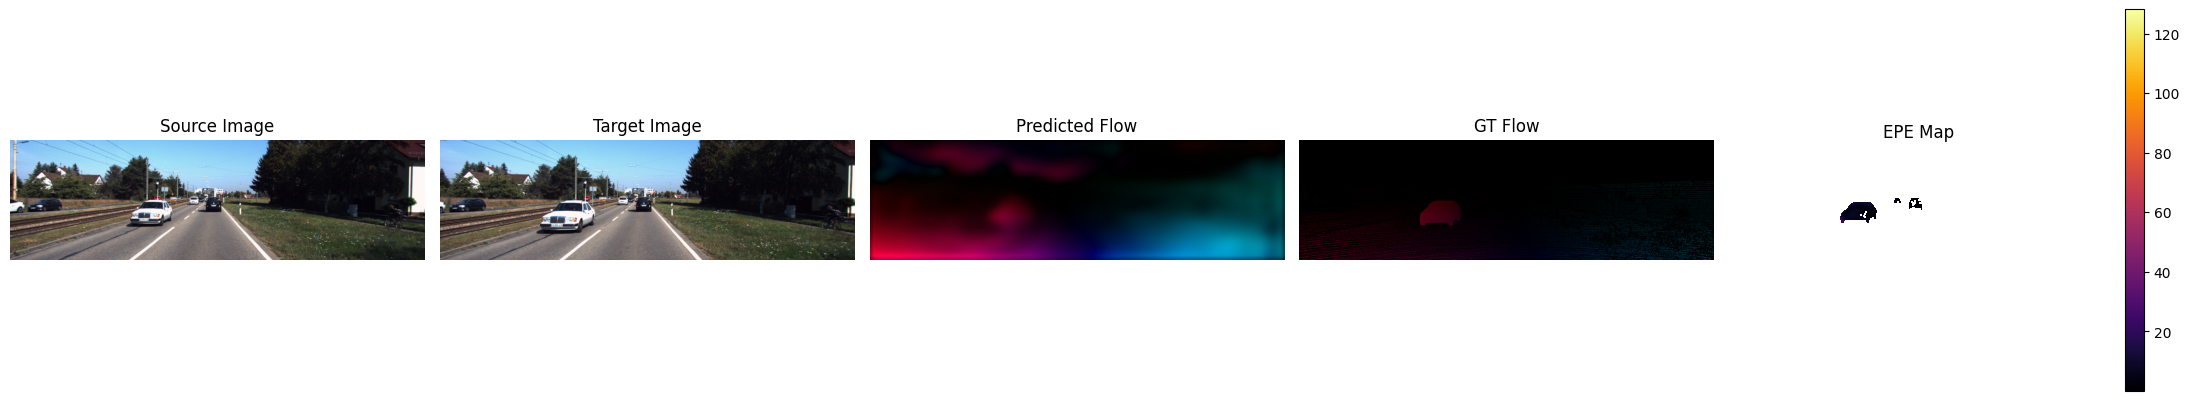

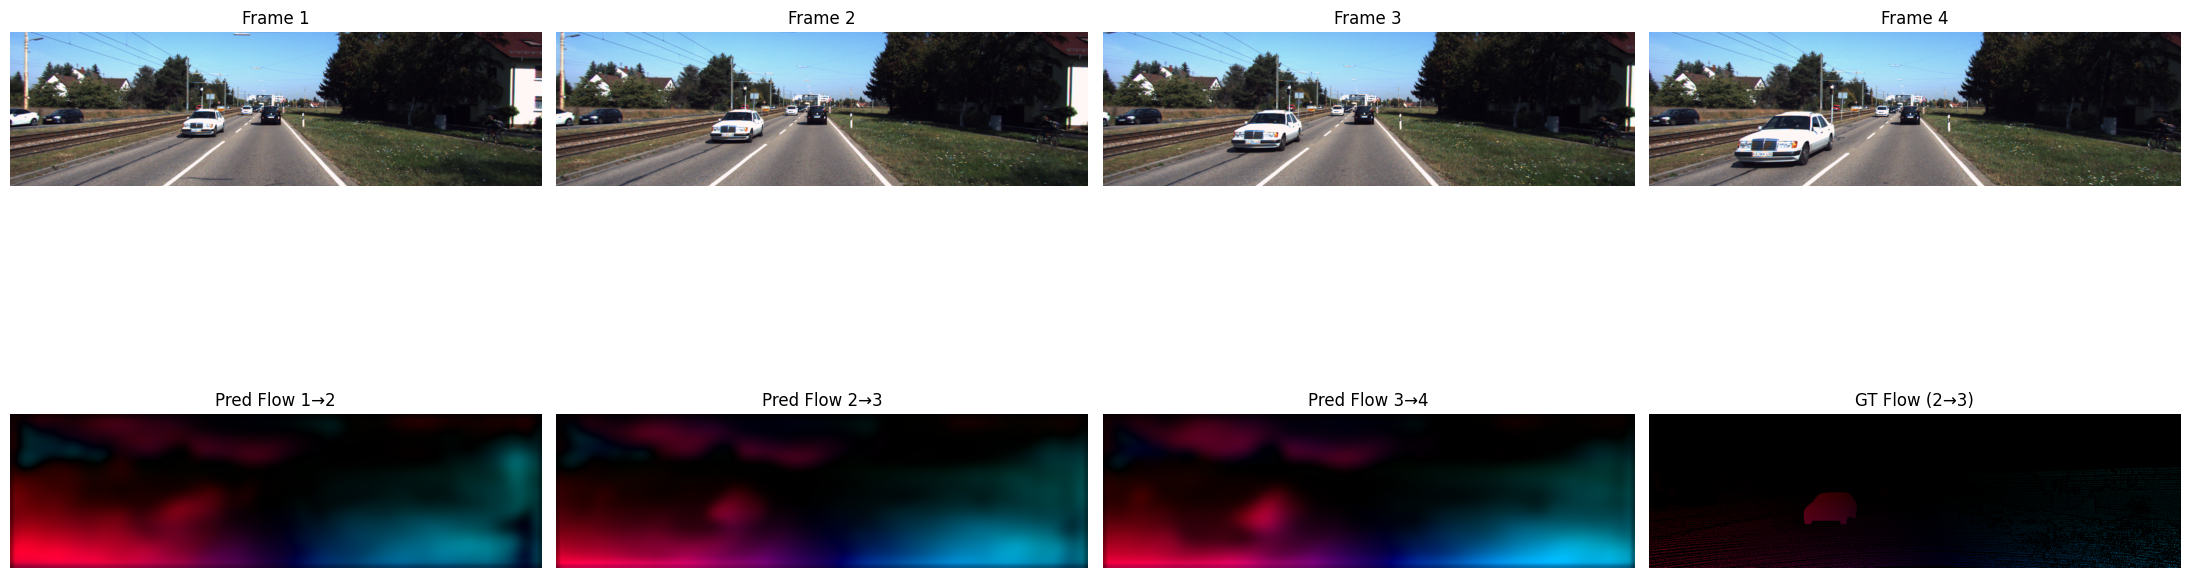

In [153]:
batch = next(iter(train_loader))

imgs = batch["imgs"].to(device)
valid = batch["valid"].to(device)

pair_encoder.eval().to(device)
visual_branch.eval().to(device)
motion_branch.eval().to(device)
fusion.eval().to(device)
uno.eval().to(device)
uno_residual_head.eval().to(device)
decoder.eval().to(device)

with torch.no_grad():
    out = forward_pipeline(
        imgs=imgs,
        pair_encoder=pair_encoder,
        visual_branch=visual_branch,
        motion_branch=motion_branch,
        fusion=fusion,
        uno=uno,
        uno_residual_head=uno_residual_head,
        decoder=decoder,
        valid=valid
    )

pred_flows = out["flows"].cpu()
print(pred_flows.shape)
visualize_batch_result(batch, pred_flows, sample_idx=0)

visualize_batch_result_centered(batch, pred_flows, sample_idx=0)
